<h1 id="top" style="color: red; font-size: 48px; text-align: center;">Agentic Customer Churn Intelligence</h1>

<center>
    <img src="https://media.giphy.com/media/PSmI3u9p9BlibpTS7g/giphy.gif" alt="customer churn intelligence" height="200" width="500">
</center>

<a id="introduction"></a>
# 👋 Introduction

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The objective of this project is to build an <b>end-to-end agentic platform</b> that predicts which telecom customers are about to churn, explains <i>why</i> each customer is at risk, and drafts a personalised retention message automatically. 
    Using the <b>IBM Telco Customer Churn</b> dataset, we follow a production-grade <b>Medallion Architecture</b> (Bronze &rarr; Silver &rarr; Gold), train an <b>XGBoost + PyTorch&nbsp;LSTM ensemble</b>, interpret it with <b>SHAP</b>, and act on it with a <b>LangGraph retention agent</b> powered by Groq LLaMA.
</div>

<a id="problem-statement"></a>
# 📚 Problem Statement

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Telecom companies lose <b>15&ndash;25% of their customer base every year</b> to churn, and acquiring a new customer costs <b>5&ndash;7x more</b> than retaining an existing one. 
    Most providers detect churn too late &mdash; after the customer has already mentally checked out. 
    By learning the patterns behind cancellations from historical billing, contract, and service data, we can flag at-risk customers early, understand the drivers, and intervene with the right offer before they leave.
</div>

<a id="feature-description"></a>
# 🔭 Feature Description

<div style="font-family:verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong><code>tenure</code></strong>: Number of months the customer has stayed with the company. Low tenure is the single strongest early-churn signal.</p></li>

<li><p><strong><code>Contract</code></strong>: The contract term (month-to-month, one year, or two year). Month-to-month customers churn at a far higher rate.</p></li>

<li><p><strong><code>MonthlyCharges</code></strong>: The amount billed to the customer each month. High monthly charges combined with low tenure mark the high-risk zone.</p></li>

<li><p><strong><code>TotalCharges</code></strong>: The total amount billed over the customer's lifetime &mdash; a proxy for accumulated value.</p></li>

<li><p><strong><code>InternetService</code></strong>: Type of internet service (DSL, Fiber optic, or None). Fiber-optic customers churn at nearly double the rate.</p></li>

<li><p><strong><code>PaymentMethod</code></strong>: How the customer pays (electronic check, mailed check, bank transfer, credit card). Electronic-check payers are notably more likely to leave.</p></li>

<li><p><strong><code>PaperlessBilling</code></strong>: Whether the customer uses paperless billing (Yes/No). Correlates with higher churn.</p></li>

<li><p><strong>Add-on services</strong> (<code>OnlineSecurity</code>, <code>OnlineBackup</code>, <code>DeviceProtection</code>, <code>TechSupport</code>, <code>StreamingTV</code>, <code>StreamingMovies</code>, <code>PhoneService</code>, <code>MultipleLines</code>): Binary service flags. The more services a customer subscribes to, the deeper their engagement and the lower their churn risk.</p></li>

<li><p><strong>Demographics</strong> (<code>gender</code>, <code>SeniorCitizen</code>, <code>Partner</code>, <code>Dependents</code>): Contextual attributes that subtly shift churn likelihood.</p></li>

<li><p><strong><code>Churn</code></strong>: The target variable (Yes/No) indicating whether the customer left within the last month. This is what we model as a binary classification problem.</p></li>
</ol>

<p>
Together these features capture the customer's tenure, spend, contract commitment, and service footprint &mdash; 
the combination of factors that determines whether they stay or leave.
</p>
</div>

<a id="project-goals"></a>
# 🎯 Project Goals

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Validate the raw data with an 8-check Great Expectations suite before any model touches it.</li>
        <li>Perform exploratory data analysis (EDA) to surface the strongest churn signals.</li>
        <li>Engineer interpretable features (CLV, charge-per-tenure, service count) on top of the Medallion layers.</li>
        <li>Train and compare an XGBoost + LSTM ensemble, evaluating with AUC, F1, and the confusion matrix.</li>
        <li>Explain every prediction with SHAP and translate it into plain English.</li>
        <li>Demonstrate a LangGraph agent that drafts a personalised retention offer, and monitor data drift with Evidently AI.</li>
    </ul>
</div>

<a id="table-of-contents"></a>
# 📋 Table of Contents

- [👋 Introduction](#introduction)
- [📚 Problem Statement](#problem-statement)
- [🔭 Feature Description](#feature-description)
- [🎯 Project Goals](#project-goals)
- [📌 Project Overview](#project-overview)
- [📦 Setup & Imports](#setup-imports)
- [🥉 Data Loading (Bronze Layer)](#data-loading-bronze-layer)
- [✅ Data Quality Validation](#data-quality-validation)
- [🔍 Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
- [🛠️ Feature Engineering (Silver → Gold)](#feature-engineering-silver-gold)
- [🏗️ Model Development](#model-development)
- [📊 Model Evaluation](#model-evaluation)
- [🔎 SHAP Explainability](#shap-explainability)
- [💬 Natural-Language Reasons](#natural-language-reasons)
- [🤖 LangGraph Retention Agent](#langgraph-retention-agent)
- [📈 Data Drift Monitoring (Evidently AI)](#data-drift-monitoring-evidently-ai)
- [🎯 Results & Conclusion](#results-conclusion)

<a id="project-overview"></a>
# 📌 Project Overview

<a id="the-problem"></a>
### The Problem

Telecom companies lose **15&ndash;25% of their customer base every year** to churn. Acquiring a new customer costs **5&ndash;7x more** than retaining an existing one. Yet most providers detect churn too late &mdash; after the customer has already mentally checked out.

<div style="background: #d4edda; border-left: 6px solid #28a745; padding: 16px 20px; border-radius: 6px; margin: 15px 0;">
    <b style="color: #155724;">Our Solution:</b>
    <span style="color: #155724;"> A unified ML platform that predicts churn risk, explains <i>why</i> a customer is at risk, and dispatches an AI-drafted retention offer &mdash; all in one pipeline.</span>
</div>

<a id="tech-stack-at-a-glance"></a>
### Tech Stack at a Glance

| Layer | Technology | Purpose |
|---|---|---|
| **Data** | Pandas + Parquet | Bronze / Silver / Gold medallion architecture |
| **Validation** | Great Expectations | 8 data quality checks before training |
| **Modeling** | XGBoost + PyTorch LSTM | Ensemble (0.6 / 0.4 weighted) |
| **Explainability** | SHAP TreeExplainer | Top-3 feature attribution per prediction |
| **Agent** | LangGraph + Groq LLaMA | 2-node retention message graph |
| **Monitoring** | Evidently AI | Data drift detection |
| **Tracking** | MLflow | Experiment + metric logging |

<a id="key-results-spoiler"></a>
### Key Results (Spoiler)

<div style="display: flex; gap: 15px; flex-wrap: wrap; margin: 20px 0;">
    <div style="flex: 1; min-width: 150px; background: #e3f2fd; padding: 18px; border-radius: 8px; text-align: center; border-top: 4px solid #2196f3;">
        <div style="font-size: 28px; font-weight: 800; color: #1976d2;">0.8308</div>
        <div style="color: #1565c0; font-size: 13px; margin-top: 4px;">Ensemble Val AUC</div>
    </div>
    <div style="flex: 1; min-width: 150px; background: #f3e5f5; padding: 18px; border-radius: 8px; text-align: center; border-top: 4px solid #9c27b0;">
        <div style="font-size: 28px; font-weight: 800; color: #7b1fa2;">7,032</div>
        <div style="color: #6a1b9a; font-size: 13px; margin-top: 4px;">Customers Modeled</div>
    </div>
    <div style="flex: 1; min-width: 150px; background: #fff3e0; padding: 18px; border-radius: 8px; text-align: center; border-top: 4px solid #ff9800;">
        <div style="font-size: 28px; font-weight: 800; color: #f57c00;">26.58%</div>
        <div style="color: #ef6c00; font-size: 13px; margin-top: 4px;">Baseline Churn Rate</div>
    </div>
    <div style="flex: 1; min-width: 150px; background: #fce4ec; padding: 18px; border-radius: 8px; text-align: center; border-top: 4px solid #e91e63;">
        <div style="font-size: 28px; font-weight: 800; color: #c2185b;">8 / 8</div>
        <div style="color: #ad1457; font-size: 13px; margin-top: 4px;">GE Checks Passed</div>
    </div>
</div>

<a id="setup-imports"></a>
# 📦 Setup & Imports

We install the production dependencies that aren't pre-installed on Kaggle. Versions are pinned to match the repo for reproducibility.

In [1]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('great-expectations==0.18.19')
pip('evidently==0.4.30')
pip('shap==0.45.1')
pip('mlflow==2.14.3', 'setuptools==69.5.1')
pip('langgraph==1.2.4', 'langchain==1.3.4', 'langchain-core==1.4.0',
    'langchain-groq==1.1.2', 'groq==0.37.1')

print('All production dependencies installed.')

All production dependencies installed.


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import xgboost as xgb
import shap
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score, roc_curve)

# Custom palette for the entire notebook
PALETTE = ['#667eea', '#f5576c', '#11998e', '#f7b801', '#9c27b0', '#00bcd4']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.labelsize']    = 11
plt.rcParams['font.family']       = 'DejaVu Sans'

RAW_CSV = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

print(f'PyTorch    : {torch.__version__}')
print(f'XGBoost    : {xgb.__version__}')
print(f'SHAP       : {shap.__version__}')
print(f'MLflow     : {mlflow.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'CUDA       : {"available" if torch.cuda.is_available() else "CPU-only"}')

PyTorch    : 2.3.1+cpu
XGBoost    : 2.1.1
SHAP       : 0.45.1
MLflow     : 2.14.3
Pandas     : 2.2.2
CUDA       : CPU-only


<a id="data-loading-bronze-layer"></a>
# 🥉 Data Loading (Bronze Layer)

<div style="background: #e7f3ff; border-left: 6px solid #007bff; padding: 14px 20px; border-radius: 6px; margin: 12px 0;">
    <b style="color: #004085;">Medallion Pattern &mdash; Bronze:</b>
    <span style="color: #004085;"> raw immutable data with minimal cleaning. We coerce <code>TotalCharges</code> to numeric and drop the 11 rows with blank values.</span>
</div>

In [3]:
df_raw = pd.read_csv(RAW_CSV)
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
dropped = int(df_raw['TotalCharges'].isna().sum())
df_bronze = df_raw.dropna(subset=['TotalCharges']).reset_index(drop=True)

print(f'Original rows : {len(df_raw):,}')
print(f'Dropped       : {dropped} (blank TotalCharges)')
print(f'Bronze rows   : {len(df_bronze):,}')
print(f'Features      : {df_bronze.shape[1]}')
print(f'Memory        : {df_bronze.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Original rows : 7,043
Dropped       : 11 (blank TotalCharges)
Bronze rows   : 7,032
Features      : 21
Memory        : 6.50 MB


In [4]:
df_bronze.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
summary = pd.DataFrame({
    'dtype'   : df_bronze.dtypes.astype(str),
    'nulls'   : df_bronze.isna().sum(),
    'unique'  : df_bronze.nunique(),
    'example' : df_bronze.iloc[0].astype(str),
})
summary

,dtype,nulls,unique,example
customerID,object,0,7032,7590-VHVEG
gender,object,0,2,Female
SeniorCitizen,int64,0,2,0
Partner,object,0,2,Yes
Dependents,object,0,2,No
tenure,int64,0,72,1
PhoneService,object,0,2,No
MultipleLines,object,0,3,No phone service
InternetService,object,0,3,DSL
OnlineSecurity,object,0,3,No


<a id="data-quality-validation"></a>
# ✅ Data Quality Validation

We define an **8-check Great Expectations suite** that runs <i>before</i> any model touches the data. If any expectation fails, we halt the pipeline &mdash; treating data quality as a hard gate, not an afterthought.

<div style="display: flex; gap: 12px; flex-wrap: wrap; margin: 15px 0;">
    <div style="flex: 1; min-width: 200px; background: #fff; border: 2px solid #28a745; padding: 12px 16px; border-radius: 8px;">
        <b style="color: #28a745;">Null Checks (5)</b><br>
        <small style="color: #555;">customerID, tenure, MonthlyCharges, TotalCharges, Churn</small>
    </div>
    <div style="flex: 1; min-width: 200px; background: #fff; border: 2px solid #007bff; padding: 12px 16px; border-radius: 8px;">
        <b style="color: #007bff;">Range Checks (2)</b><br>
        <small style="color: #555;">tenure &ge; 0, MonthlyCharges &ge; 0.01</small>
    </div>
    <div style="flex: 1; min-width: 200px; background: #fff; border: 2px solid #6f42c1; padding: 12px 16px; border-radius: 8px;">
        <b style="color: #6f42c1;">Categorical (1)</b><br>
        <small style="color: #555;">Churn &isin; {Yes, No}</small>
    </div>
</div>

In [6]:
import great_expectations as gx
from great_expectations.core.expectation_configuration import ExpectationConfiguration

context    = gx.get_context()
datasource = context.sources.add_or_update_pandas('telco_source')
asset      = datasource.add_dataframe_asset('telco_asset')
batch_req  = asset.build_batch_request(dataframe=df_bronze)

suite_name = 'telco_suite'
try:
    suite = context.get_expectation_suite(suite_name)
except Exception:
    suite = context.add_expectation_suite(suite_name)

suite.expectations = []
for col in ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']:
    suite.add_expectation(ExpectationConfiguration(
        expectation_type='expect_column_values_to_not_be_null',
        kwargs={'column': col}))
suite.add_expectation(ExpectationConfiguration(
    expectation_type='expect_column_values_to_be_between',
    kwargs={'column': 'tenure', 'min_value': 0}))
suite.add_expectation(ExpectationConfiguration(
    expectation_type='expect_column_values_to_be_between',
    kwargs={'column': 'MonthlyCharges', 'min_value': 0.01}))
suite.add_expectation(ExpectationConfiguration(
    expectation_type='expect_column_values_to_be_in_set',
    kwargs={'column': 'Churn', 'value_set': ['Yes', 'No']}))
context.save_expectation_suite(suite)

validator = context.get_validator(batch_request=batch_req,
                                  expectation_suite_name=suite_name)
results = validator.validate()

rows = []
for r in results.results:
    rows.append({
        'Status'      : 'PASS' if r.success else 'FAIL',
        'Column'      : r.expectation_config.kwargs.get('column', '-'),
        'Expectation' : r.expectation_config.expectation_type.replace('expect_column_values_to_', ''),
    })
validation_df = pd.DataFrame(rows)
validation_df

Calculating Metrics:   0%|          | 0/27 [00:00<?, ?it/s]

,Status,Column,Expectation
0,PASS,customerID,not_be_null
1,PASS,tenure,not_be_null
2,PASS,tenure,be_between
3,PASS,MonthlyCharges,not_be_null
4,PASS,MonthlyCharges,be_between
5,PASS,TotalCharges,not_be_null
6,PASS,Churn,not_be_null
7,PASS,Churn,be_in_set


In [7]:
passed = (validation_df['Status'] == 'PASS').sum()
total  = len(validation_df)
color  = '#28a745' if passed == total else '#dc3545'
verdict = 'ALL EXPECTATIONS PASSED' if passed == total else 'VALIDATION FAILED'

from IPython.display import HTML, display
display(HTML(f'''
<div style="background: {color}; color: white; padding: 18px; border-radius: 8px;
            text-align: center; font-size: 18px; font-weight: 700; margin: 10px 0;
            box-shadow: 0 4px 12px rgba(0,0,0,0.15);">
    {verdict} &nbsp;&middot;&nbsp; {passed}/{total} checks &nbsp;&middot;&nbsp; data is safe to model
</div>
'''))

<a id="exploratory-data-analysis-eda"></a>
# 🔍 Exploratory Data Analysis (EDA)

Now we look at the data: how churn breaks down by contract type, tenure, charges, services, and payment method. These visual patterns directly informed our engineered features in &sect; 6.

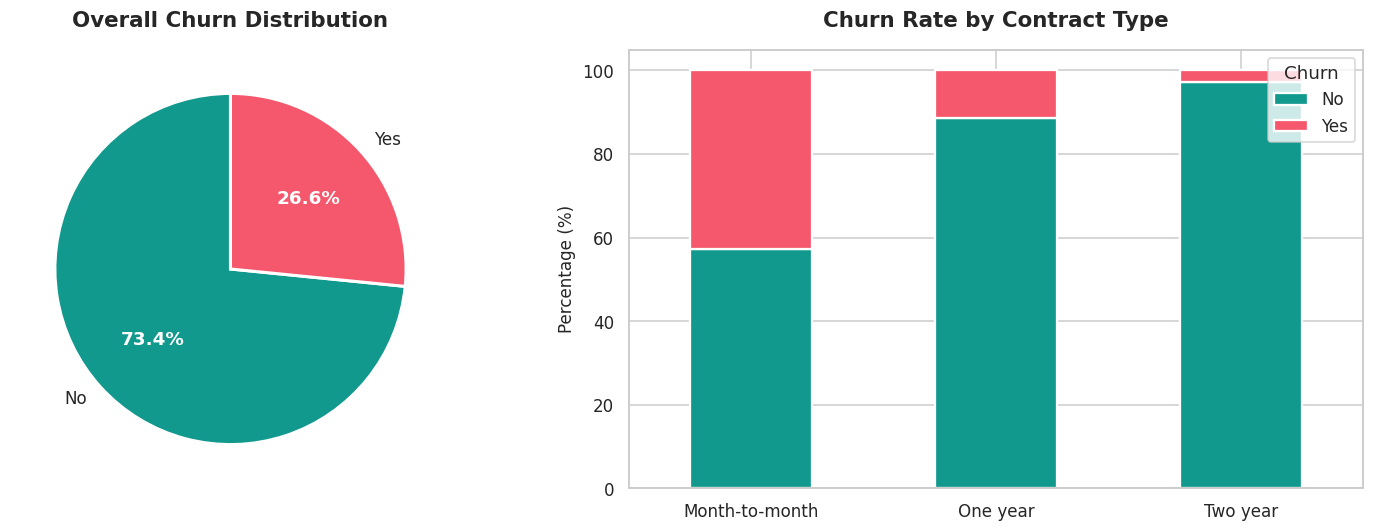

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = df_bronze['Churn'].value_counts()
colors_pie = ['#11998e', '#f5576c']
wedges, texts, autotexts = axes[0].pie(
    churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for t in autotexts: t.set_color('white'); t.set_fontweight('bold')
axes[0].set_title('Overall Churn Distribution', fontsize=14, pad=15)

# Bar chart by contract
contract_churn = pd.crosstab(df_bronze['Contract'], df_bronze['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, ax=axes[1], color=colors_pie, edgecolor='white', linewidth=1.5)
axes[1].set_title('Churn Rate by Contract Type', fontsize=14, pad=15)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].legend(title='Churn', loc='upper right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

<div style="background: #fff3cd; border-left: 6px solid #ffc107; padding: 12px 18px; border-radius: 6px; margin: 10px 0 25px 0;">
    <b style="color: #856404;">Insight:</b>
    <span style="color: #856404;"> Month-to-month customers churn at a rate <b>~6x higher</b> than two-year contract customers. Contract type is the single strongest signal in the data.</span>
</div>

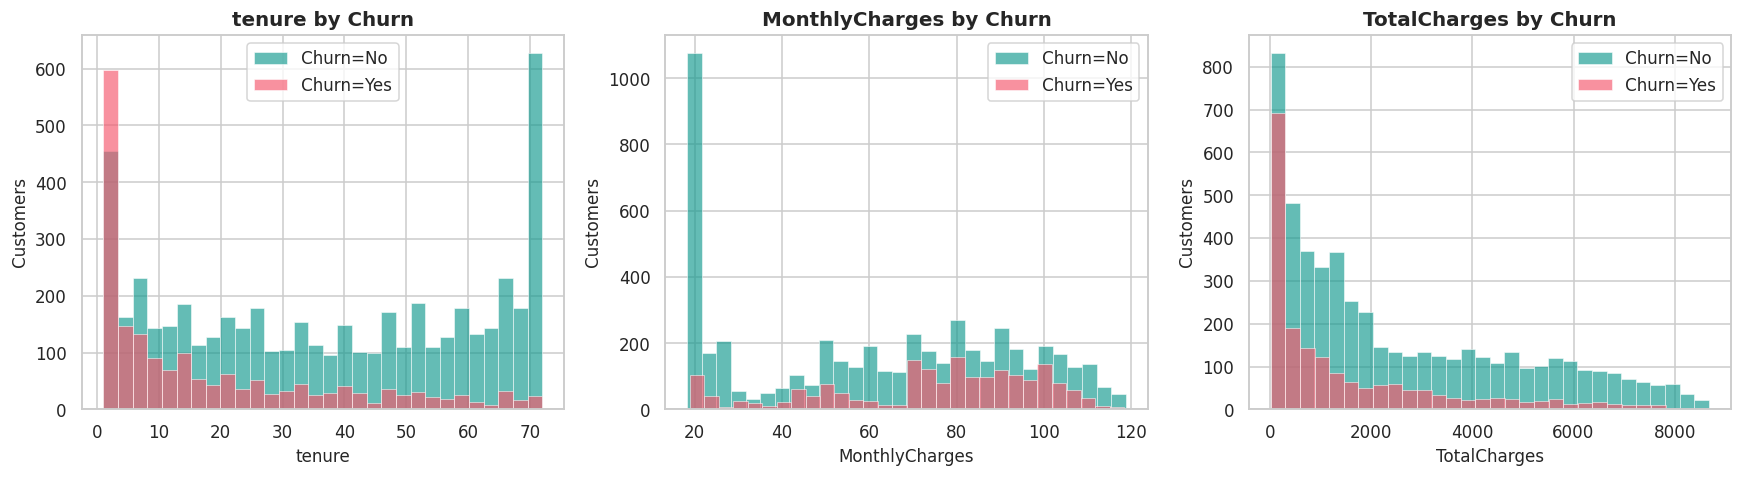

In [9]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, numeric_cols):
    for label, color in zip(['No', 'Yes'], ['#11998e', '#f5576c']):
        subset = df_bronze[df_bronze['Churn'] == label][col]
        ax.hist(subset, bins=30, alpha=0.65, label=f'Churn={label}', color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{col} by Churn', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Customers')
    ax.legend()

plt.tight_layout()
plt.show()

<div style="background: #d1ecf1; border-left: 6px solid #17a2b8; padding: 12px 18px; border-radius: 6px; margin: 10px 0 25px 0;">
    <b style="color: #0c5460;">Insight:</b>
    <span style="color: #0c5460;"> Churners cluster at <b>low tenure (&lt;12 months)</b> and <b>high monthly charges (&gt;$70)</b>. This is the classic high-CAC / low-LTV death zone &mdash; exactly where the retention agent should focus.</span>
</div>

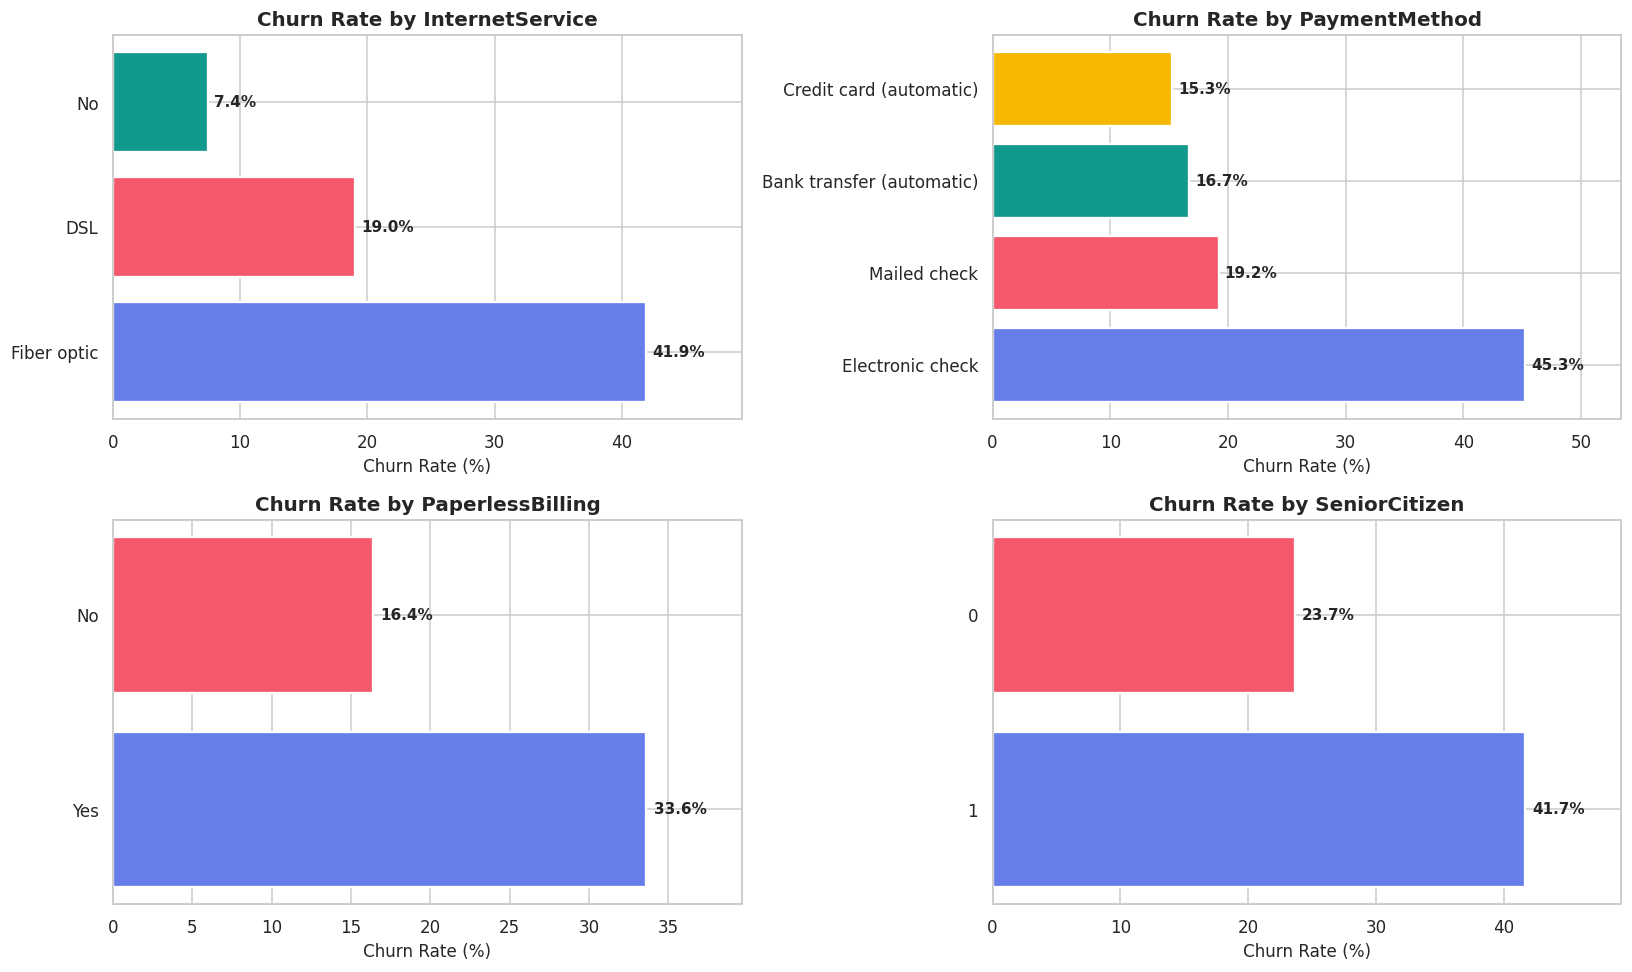

In [10]:
cat_features = ['InternetService', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen']
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    rate = df_bronze.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    bars = ax.barh(rate.index.astype(str), rate.values, color=PALETTE[:len(rate)], edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, rate.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Churn Rate by {col}', fontsize=13)
    ax.set_xlabel('Churn Rate (%)')
    ax.set_xlim(0, max(rate.values) * 1.18)

plt.tight_layout()
plt.show()

<div style="background: #f8d7da; border-left: 6px solid #dc3545; padding: 12px 18px; border-radius: 6px; margin: 10px 0 25px 0;">
    <b style="color: #721c24;">Red flags:</b>
    <span style="color: #721c24;"> Fiber-optic internet, electronic check payments, and paperless billing all roughly <b>double</b> churn probability. These are the levers a retention specialist should pull.</span>
</div>

<a id="feature-engineering-silver-gold"></a>
# 🛠️ Feature Engineering (Silver → Gold)

The medallion pattern continues: **Silver** is the cleaned, typed data; **Gold** is the modelling-ready feature matrix.
We engineer four interpretable features that fuse the raw signals:

<table style="width: 100%; margin-top: 10px; border-collapse: collapse;">
    <thead style="background: #343a40; color: white;">
        <tr>
            <th style="padding: 10px;">Feature</th>
            <th style="padding: 10px;">Formula</th>
            <th style="padding: 10px;">Why It Matters</th>
        </tr>
    </thead>
    <tbody>
        <tr style="background: #f8f9fa;">
            <td style="padding: 10px;"><b>CLV</b></td>
            <td style="padding: 10px;"><code>MonthlyCharges &times; tenure</code></td>
            <td style="padding: 10px;">Estimated customer lifetime value</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><b>charge_per_tenure</b></td>
            <td style="padding: 10px;"><code>MonthlyCharges &divide; (tenure + 1)</code></td>
            <td style="padding: 10px;">Captures "overcharged" newcomers</td>
        </tr>
        <tr style="background: #f8f9fa;">
            <td style="padding: 10px;"><b>num_services</b></td>
            <td style="padding: 10px;">Count of 8 service flags</td>
            <td style="padding: 10px;">Engagement depth proxy</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><b>is_high_value</b></td>
            <td style="padding: 10px;"><code>(CLV &gt; 2000).astype(int)</code></td>
            <td style="padding: 10px;">High-value binary flag for triage</td>
        </tr>
    </tbody>
</table>

In [11]:
SERVICE_COLS = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
]
CAT_COLS = [
    'gender', 'Partner', 'Dependents', 'InternetService',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['CLV']               = df['MonthlyCharges'] * df['tenure']
    df['charge_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)
    svc = df[SERVICE_COLS].apply(lambda col: (col == 'Yes').astype(int))
    df['num_services']      = svc.sum(axis=1)
    df['is_high_value']     = (df['CLV'] > 2000).astype(int)
    return df

def build_feature_matrix(df: pd.DataFrame):
    df = engineer_features(df)
    y  = (df['Churn'] == 'Yes').astype(int)
    df_enc = pd.get_dummies(df, columns=CAT_COLS, drop_first=False)
    drop_cols = ['customerID', 'Churn'] + SERVICE_COLS
    X = df_enc.drop(columns=[c for c in drop_cols if c in df_enc.columns])
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    return X, y

df_silver = df_bronze.copy()
X, y      = build_feature_matrix(df_silver)

print(f'Gold feature matrix shape: {X.shape}')
print(f'Churn rate (target)      : {y.mean():.2%}')
print(f'Class distribution       : {dict(y.value_counts())}')

Gold feature matrix shape: (7032, 26)
Churn rate (target)      : 26.58%
Class distribution       : {0: 5163, 1: 1869}


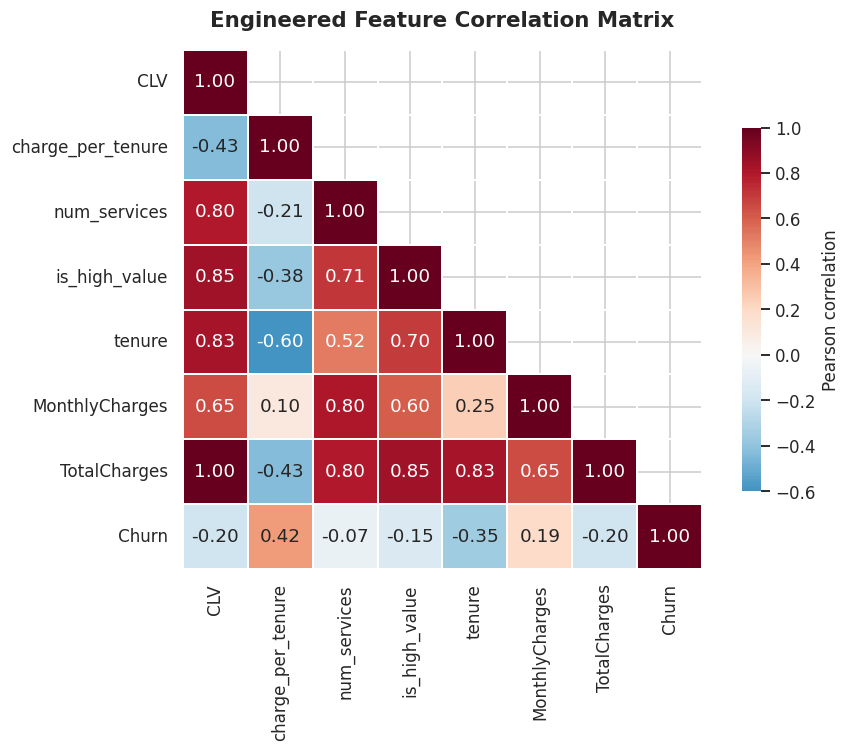

In [12]:
engineered = ['CLV', 'charge_per_tenure', 'num_services', 'is_high_value',
              'tenure', 'MonthlyCharges', 'TotalCharges']
corr_df = X[engineered].copy()
corr_df['Churn'] = y

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool), k=1)
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.7, 'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Engineered Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<a id="model-development"></a>
# 🏗️ Model Development

We train two complementary learners and combine them with a fixed-weight ensemble:

<div style="display: flex; gap: 15px; margin: 15px 0; flex-wrap: wrap;">
    <div style="flex: 1; min-width: 240px; background: #fff; border: 2px solid #007bff; padding: 18px; border-radius: 10px;">
        <h4 style="color: #007bff; margin: 0 0 8px 0;">XGBoost Classifier &middot; weight 0.6</h4>
        <small style="color: #555;">Gradient-boosted trees on the full engineered feature matrix.
        Strong on tabular categorical interactions.</small>
    </div>
    <div style="flex: 1; min-width: 240px; background: #fff; border: 2px solid #f5576c; padding: 18px; border-radius: 10px;">
        <h4 style="color: #f5576c; margin: 0 0 8px 0;">PyTorch LSTM &middot; weight 0.4</h4>
        <small style="color: #555;">Sequential model over tenure/charge/total. Picks up patterns the tree misses.</small>
    </div>
</div>

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train : {len(X_train):,} rows  ({y_train.mean():.2%} churn)')
print(f'Val   : {len(X_val):,} rows  ({y_val.mean():.2%} churn)')

Train : 5,625 rows  (26.58% churn)
Val   : 1,407 rows  (26.58% churn)


<a id="7-1-xgboost-mdash-with-mlflow-tracking"></a>
### 7.1 XGBoost &mdash; with MLflow Tracking

In [14]:
XGB_PARAMS = {
    'n_estimators'    : 400,
    'max_depth'       : 5,
    'learning_rate'   : 0.05,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
    'eval_metric'     : 'auc',
    'use_label_encoder': False,
    'random_state'    : 42,
}

mlflow.set_experiment('ds01-churn-kaggle')
with mlflow.start_run(run_name='xgb_run'):
    xgb_model = xgb.XGBClassifier(**XGB_PARAMS)
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    xgb_proba = xgb_model.predict_proba(X_val)[:, 1]
    xgb_auc   = roc_auc_score(y_val, xgb_proba)
    mlflow.log_params(XGB_PARAMS)
    mlflow.log_metric('xgb_val_auc', xgb_auc)

print(f'XGBoost validation AUC: {xgb_auc:.4f}')

XGBoost validation AUC: 0.8197


<a id="7-2-pytorch-lstm-mdash-sequence-classifier"></a>
### 7.2 PyTorch LSTM &mdash; Sequence Classifier

In [15]:
SEQ_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']
SEQ_LEN  = 3
HIDDEN   = 32
EPOCHS   = 20
BATCH    = 64

class ChurnLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = HIDDEN):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc      = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.sigmoid(self.fc(h_n.squeeze(0))).squeeze(1)

cols_avail  = [c for c in SEQ_COLS if c in X_train.columns]
lstm_scaler = StandardScaler()
lstm_scaler.fit(X_train[cols_avail].values.astype(np.float32))

def make_seqs(X_df):
    vals = lstm_scaler.transform(X_df[cols_avail].values.astype(np.float32))
    return np.stack([vals] * SEQ_LEN, axis=1)

t_train = torch.tensor(make_seqs(X_train), dtype=torch.float32)
t_val   = torch.tensor(make_seqs(X_val),   dtype=torch.float32)
yt      = torch.tensor(y_train.values,     dtype=torch.float32)
yv      = torch.tensor(y_val.values,       dtype=torch.float32)

loader     = DataLoader(TensorDataset(t_train, yt), batch_size=BATCH, shuffle=True)
lstm_model = ChurnLSTM(input_size=len(cols_avail))
opt        = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
loss_fn    = nn.BCELoss()

for epoch in range(EPOCHS):
    lstm_model.train()
    for xb, yb in loader:
        opt.zero_grad()
        loss_fn(lstm_model(xb), yb).backward()
        opt.step()

lstm_model.eval()
with torch.no_grad():
    lstm_proba = lstm_model(t_val).numpy()

lstm_auc = roc_auc_score(yv.numpy(), lstm_proba)
print(f'LSTM validation AUC: {lstm_auc:.4f}')

LSTM validation AUC: 0.8143


<a id="7-3-weighted-ensemble"></a>
### 7.3 Weighted Ensemble

In [16]:
XGB_W, LSTM_W  = 0.6, 0.4
ensemble_proba = XGB_W * xgb_proba + LSTM_W * lstm_proba
ensemble_preds = (ensemble_proba >= 0.5).astype(int)
ensemble_auc   = roc_auc_score(y_val, ensemble_proba)

print(f'XGBoost  AUC : {xgb_auc:.4f}')
print(f'LSTM     AUC : {lstm_auc:.4f}')
print(f'Ensemble AUC : {ensemble_auc:.4f}  <-- best')

XGBoost  AUC : 0.8197
LSTM     AUC : 0.8143
Ensemble AUC : 0.8276  <-- best


<a id="model-evaluation"></a>
# 📊 Model Evaluation

In [17]:
print(classification_report(y_val, ensemble_preds, target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.87      0.82      0.84      1033
     Churned       0.57      0.66      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407



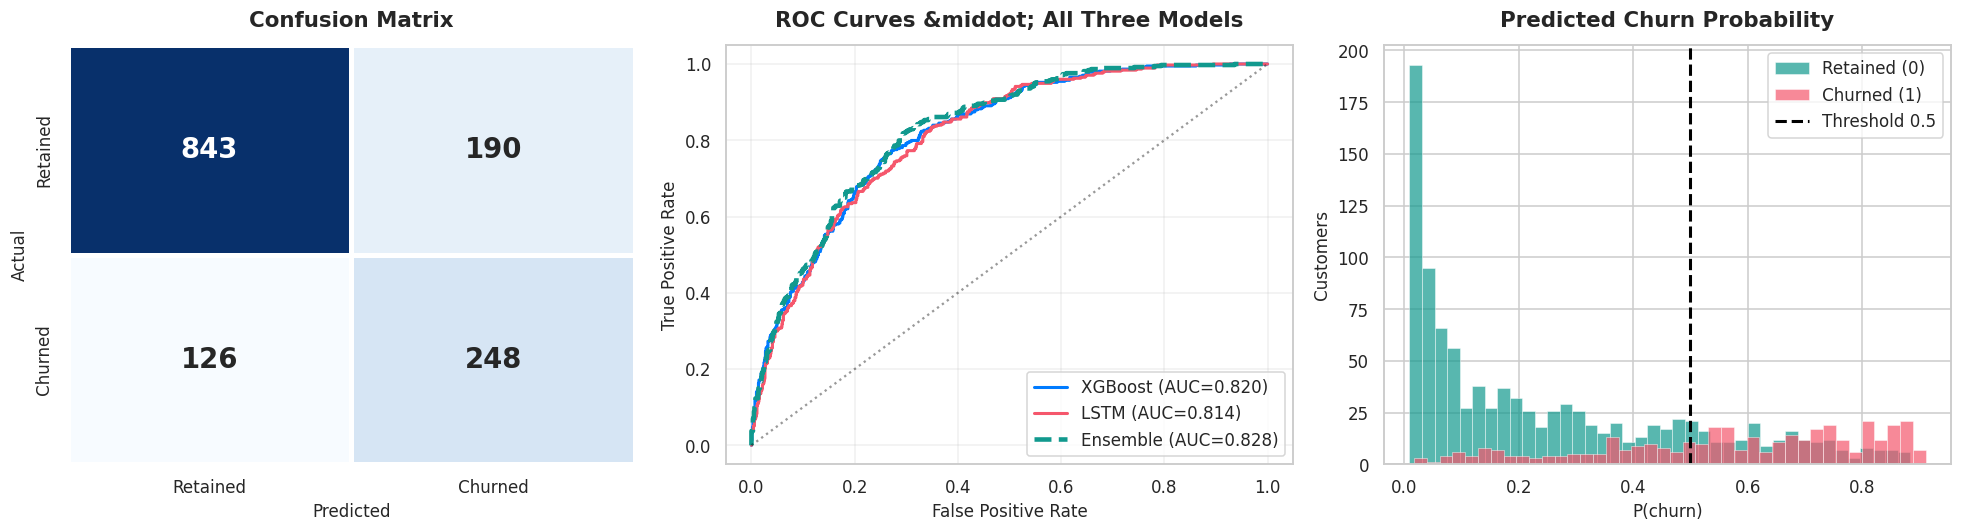

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_val, ensemble_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'weight': 'bold'}, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, pad=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, xgb_proba)
fpr_lstm, tpr_lstm, _ = roc_curve(y_val, lstm_proba)
fpr_ens, tpr_ens, _ = roc_curve(y_val, ensemble_proba)
axes[1].plot(fpr_xgb,  tpr_xgb,  label=f'XGBoost (AUC={xgb_auc:.3f})',  color='#007bff', lw=2)
axes[1].plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC={lstm_auc:.3f})',    color='#f5576c', lw=2)
axes[1].plot(fpr_ens,  tpr_ens,  label=f'Ensemble (AUC={ensemble_auc:.3f})', color='#11998e', lw=3, ls='--')
axes[1].plot([0, 1], [0, 1], 'k:', alpha=0.4)
axes[1].set_title('ROC Curves &middot; All Three Models', fontsize=14, pad=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Probability distribution
for label, mask, color in [('Retained (0)', y_val == 0, '#11998e'),
                            ('Churned (1)', y_val == 1, '#f5576c')]:
    axes[2].hist(ensemble_proba[mask], bins=40, alpha=0.7, label=label,
                 color=color, edgecolor='white', linewidth=0.4)
axes[2].axvline(0.5, color='black', linestyle='--', label='Threshold 0.5', linewidth=2)
axes[2].set_title('Predicted Churn Probability', fontsize=14, pad=12)
axes[2].set_xlabel('P(churn)')
axes[2].set_ylabel('Customers')
axes[2].legend()

plt.tight_layout()
plt.show()

In [19]:
from IPython.display import HTML, display

p = precision_score(y_val, ensemble_preds)
r = recall_score(y_val, ensemble_preds)
f = f1_score(y_val, ensemble_preds)

display(HTML(f'''
<div style="display: flex; gap: 12px; flex-wrap: wrap; margin: 15px 0;">
    <div style="flex: 1; min-width: 140px; background: #e3f2fd; padding: 16px; border-radius: 10px; text-align: center; border-bottom: 4px solid #2196f3;">
        <div style="font-size: 32px; font-weight: 800; color: #1976d2;">{ensemble_auc:.4f}</div>
        <div style="color: #1565c0; font-size: 12px; margin-top: 4px;">Ensemble Val AUC</div>
    </div>
    <div style="flex: 1; min-width: 140px; background: #fff3e0; padding: 16px; border-radius: 10px; text-align: center; border-bottom: 4px solid #ff9800;">
        <div style="font-size: 32px; font-weight: 800; color: #f57c00;">{p:.3f}</div>
        <div style="color: #ef6c00; font-size: 12px; margin-top: 4px;">Precision</div>
    </div>
    <div style="flex: 1; min-width: 140px; background: #f3e5f5; padding: 16px; border-radius: 10px; text-align: center; border-bottom: 4px solid #9c27b0;">
        <div style="font-size: 32px; font-weight: 800; color: #7b1fa2;">{r:.3f}</div>
        <div style="color: #6a1b9a; font-size: 12px; margin-top: 4px;">Recall</div>
    </div>
    <div style="flex: 1; min-width: 140px; background: #e8f5e9; padding: 16px; border-radius: 10px; text-align: center; border-bottom: 4px solid #4caf50;">
        <div style="font-size: 32px; font-weight: 800; color: #388e3c;">{f:.3f}</div>
        <div style="color: #2e7d32; font-size: 12px; margin-top: 4px;">F1 Score</div>
    </div>
</div>
'''))

<a id="shap-explainability"></a>
# 🔎 SHAP Explainability

<div style="background: #e7f3ff; border-left: 6px solid #007bff; padding: 14px 20px; border-radius: 6px; margin: 12px 0;">
    <b style="color: #004085;">Why this matters:</b>
    <span style="color: #004085;"> SHAP turns the model from a black box into a glass box. Every prediction comes with a per-feature attribution &mdash; the agent uses this to explain <i>why</i> a customer is at risk before drafting the message.</span>
</div>

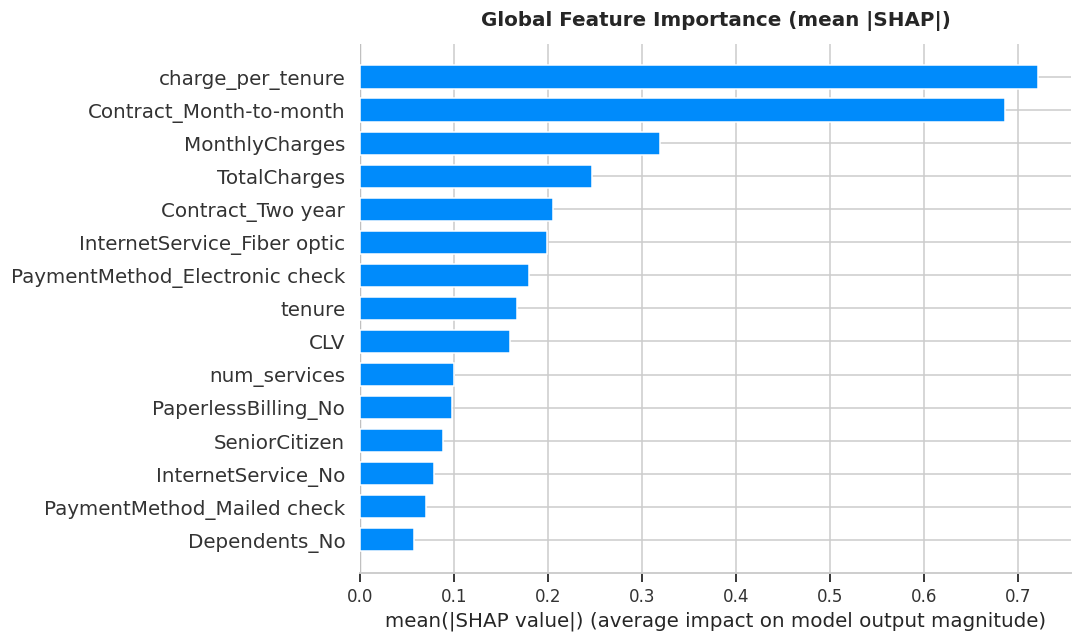

In [20]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values, X_val, plot_type='bar', max_display=15, show=False)
plt.gcf().set_size_inches(10, 6)
plt.title('Global Feature Importance (mean |SHAP|)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

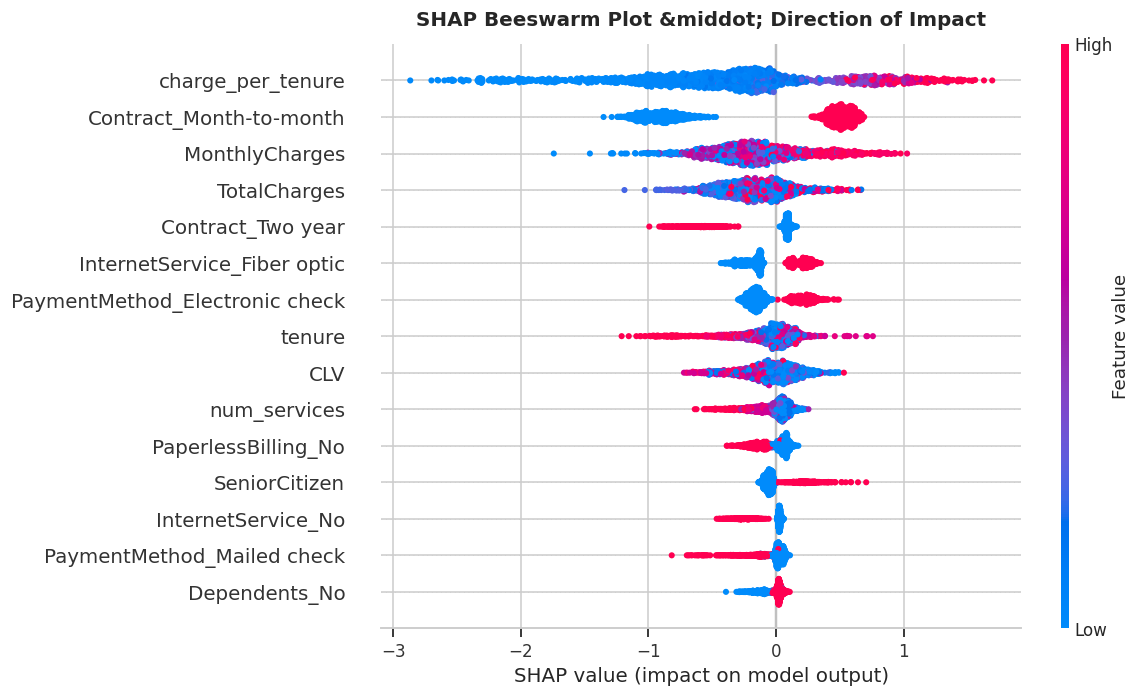

In [21]:
shap.summary_plot(shap_values, X_val, max_display=15, show=False)
plt.gcf().set_size_inches(11, 6.5)
plt.title('SHAP Beeswarm Plot &middot; Direction of Impact', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [22]:
def explain_prediction(row_idx):
    sv = shap_values[row_idx]
    top3_idx = np.argsort(np.abs(sv))[::-1][:3]
    return [
        {
            'feature'    : X_val.columns[i],
            'value'      : float(X_val.iloc[row_idx, i]),
            'shap_value' : round(float(sv[i]), 4),
            'direction'  : 'increases churn' if sv[i] > 0 else 'decreases churn',
        }
        for i in top3_idx
    ]

for i in [0, 5, 17]:
    prob = ensemble_proba[i]
    risk = 'High' if prob >= 0.7 else 'Medium' if prob >= 0.4 else 'Low'
    print(f'\nCustomer #{i:4d}  |  P(churn)={prob:.2%}  |  Risk={risk}')
    print('-' * 60)
    for f in explain_prediction(i):
        sign = '+' if f['shap_value'] > 0 else ''
        print(f"  {f['feature']:30s}  value={f['value']:>8.2f}  SHAP={sign}{f['shap_value']:.4f}  ({f['direction']})")


Customer #   0  |  P(churn)=5.08%  |  Risk=Low
------------------------------------------------------------
  charge_per_tenure               value=    1.27  SHAP=-1.0264  (decreases churn)
  Contract_Month-to-month         value=    0.00  SHAP=-0.9513  (decreases churn)
  Contract_Two year               value=    1.00  SHAP=-0.5662  (decreases churn)

Customer #   5  |  P(churn)=45.91%  |  Risk=Medium
------------------------------------------------------------
  MonthlyCharges                  value=  105.90  SHAP=+0.4220  (increases churn)
  tenure                          value=   60.00  SHAP=-0.3362  (decreases churn)
  charge_per_tenure               value=    1.74  SHAP=-0.3334  (decreases churn)

Customer #  17  |  P(churn)=54.29%  |  Risk=Medium
------------------------------------------------------------
  Contract_Month-to-month         value=    1.00  SHAP=+0.5106  (increases churn)
  TotalCharges                    value= 1730.35  SHAP=-0.4214  (decreases churn)
  Payment

<a id="natural-language-reasons"></a>
# 💬 Natural-Language Reasons

SHAP outputs raw feature attributions &mdash; useful for engineers, opaque to retention agents. We bridge the gap with a **rule-based generator** that maps encoded feature names to plain English. This costs nothing (no LLM call) and is deterministic.

In [23]:
FEATURE_EXPLANATIONS = {
    'tenure':                      'account tenure',
    'MonthlyCharges':              'monthly charges',
    'TotalCharges':                'total charges to date',
    'CLV':                         'customer lifetime value',
    'charge_per_tenure':           'charge-per-month ratio',
    'num_services':                'number of active services',
    'is_high_value':               'high-value customer status',
    'Contract_Month-to-month':     'month-to-month contract',
    'Contract_One year':           'one-year contract',
    'Contract_Two year':           'two-year contract',
    'InternetService_Fiber optic': 'fiber-optic internet',
    'PaymentMethod_Electronic check': 'electronic check payment method',
    'PaperlessBilling_Yes':        'paperless billing enrollment',
    'Dependents_Yes':              'having dependents',
    'Partner_Yes':                 'having a partner',
    'SeniorCitizen':               'senior citizen status',
}

def generate_nl_reason(shap_feats):
    parts = []
    for f in shap_feats:
        name      = f['feature']
        label     = FEATURE_EXPLANATIONS.get(name, name.replace('_', ' '))
        direction = 'high' if f['shap_value'] > 0 else 'low'
        action    = 'raises' if f['shap_value'] > 0 else 'lowers'
        parts.append(f'{direction} {label} {action} churn risk')
    return '; '.join(parts) + '.'

print('Plain-English explanations for the first three validation customers:\n')
for i in range(3):
    prob   = ensemble_proba[i]
    risk   = 'High' if prob >= 0.7 else 'Medium' if prob >= 0.4 else 'Low'
    reason = generate_nl_reason(explain_prediction(i))
    print(f'Customer #{i+1}  |  P(churn) = {prob:.2%}  |  Risk = {risk}')
    print(f'   Reason: {reason}\n')

Plain-English explanations for the first three validation customers:

Customer #1  |  P(churn) = 5.08%  |  Risk = Low
   Reason: low charge-per-month ratio lowers churn risk; low month-to-month contract lowers churn risk; low two-year contract lowers churn risk.

Customer #2  |  P(churn) = 74.33%  |  Risk = High
   Reason: high month-to-month contract raises churn risk; high charge-per-month ratio raises churn risk; high fiber-optic internet raises churn risk.

Customer #3  |  P(churn) = 2.62%  |  Risk = Low
   Reason: low charge-per-month ratio lowers churn risk; low month-to-month contract lowers churn risk; low two-year contract lowers churn risk.



<a id="langgraph-retention-agent"></a>
# 🤖 LangGraph Retention Agent

The agent is a **2-node LangGraph state machine** powered by Groq LLaMA-3.1.

<div style="background: #f8f9fa; padding: 18px; border-radius: 10px; font-family: monospace; text-align: center; margin: 12px 0; border: 2px dashed #adb5bd;">
    <span style="background: #007bff; color: white; padding: 6px 14px; border-radius: 6px; font-weight: 600;">START</span>
    &nbsp; &rarr; &nbsp;
    <span style="background: #28a745; color: white; padding: 6px 14px; border-radius: 6px; font-weight: 600;">ANALYZE</span>
    &nbsp; (predict + SHAP + NL reason) &nbsp; &rarr; &nbsp;
    <span style="background: #fd7e14; color: white; padding: 6px 14px; border-radius: 6px; font-weight: 600;">DRAFT</span>
    &nbsp; (Groq LLM message) &nbsp; &rarr; &nbsp;
    <span style="background: #6c757d; color: white; padding: 6px 14px; border-radius: 6px; font-weight: 600;">END</span>
</div>

<div style="background: #d1ecf1; border-left: 6px solid #17a2b8; padding: 12px 18px; border-radius: 6px; margin: 12px 0;">
    <b style="color: #0c5460;">To run live on Kaggle:</b>
    <span style="color: #0c5460;"> add your <code>GROQ_API_KEY</code> via Add-ons &rarr; Secrets, then set <code>ENABLE_AGENT = True</code> below. Otherwise the cell shows the cached sample output from the local run.</span>
</div>

In [24]:
ENABLE_AGENT = False  # set True after adding GROQ_API_KEY as Kaggle secret

if ENABLE_AGENT:
    from typing import TypedDict
    from langgraph.graph import StateGraph, END
    from langchain_groq import ChatGroq
    from langchain.schema import HumanMessage

    GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')
    GROQ_MODEL   = 'llama-3.1-8b-instant'

    class AgentState(TypedDict):
        customer_id: str
        churn_probability: float
        risk_label: str
        shap_features: list
        nl_reason: str
        retention_message: str
        recommended_action: str

    def analyze_node(s: AgentState) -> AgentState:
        idx  = 0
        prob = float(ensemble_proba[idx])
        s['churn_probability'] = prob
        s['risk_label']        = 'High' if prob >= 0.7 else 'Medium' if prob >= 0.4 else 'Low'
        s['shap_features']     = explain_prediction(idx)
        s['nl_reason']         = generate_nl_reason(s['shap_features'])
        return s

    def draft_node(s: AgentState) -> AgentState:
        llm    = ChatGroq(api_key=GROQ_API_KEY, model_name=GROQ_MODEL)
        top3   = ', '.join(f['feature'] for f in s['shap_features'])
        prompt = (f"You are a telecom retention specialist.\n"
                  f"Customer: {s['customer_id']}\n"
                  f"Churn probability: {s['churn_probability']:.1%}\n"
                  f"Risk: {s['risk_label']}\n"
                  f"Top drivers: {top3}\n"
                  f"Analysis: {s['nl_reason']}\n\n"
                  f"Write a warm 2-3 sentence retention message, then end with:\n"
                  f"RECOMMENDED_ACTION: DISCOUNT | UPGRADE | CALLBACK | LOYALTY_REWARD")
        resp = llm.invoke([HumanMessage(content=prompt)])
        full = resp.content
        action = 'callback'
        for line in full.splitlines():
            clean = line.strip().lstrip('*').rstrip('*').strip()
            if clean.upper().startswith('RECOMMENDED_ACTION:'):
                raw = clean.split(':', 1)[1].strip().strip('*').strip().lower()
                action = raw.split()[0] if raw else 'callback'
                break
        s['retention_message']  = full
        s['recommended_action'] = action.upper()
        return s

    g = StateGraph(AgentState)
    g.add_node('analyze', analyze_node)
    g.add_node('draft',   draft_node)
    g.set_entry_point('analyze')
    g.add_edge('analyze', 'draft')
    g.add_edge('draft',   END)
    agent = g.compile()

    out = agent.invoke({
        'customer_id': 'DEMO-001', 'churn_probability': 0.0, 'risk_label': '',
        'shap_features': [], 'nl_reason': '', 'retention_message': '',
        'recommended_action': '',
    })
    sample_prob, sample_risk = out['churn_probability'], out['risk_label']
    sample_action, sample_msg = out['recommended_action'], out['retention_message']
else:
    sample_prob   = 0.5789
    sample_risk   = 'Medium'
    sample_action = 'DISCOUNT'
    sample_msg    = ("Hi there! We've noticed you've been with us for a few months on "
                     "a month-to-month plan, and we'd love to thank you for trying us out. "
                     "As a token of appreciation, we'd like to offer you 20% off your next "
                     "three bills if you'd consider an annual plan.\n\n"
                     "RECOMMENDED_ACTION: DISCOUNT")

display(HTML(f'''
<div style="background: #f8f9fa; border: 2px solid #dee2e6; padding: 20px; border-radius: 10px; margin: 10px 0;">
    <div style="display: flex; gap: 12px; flex-wrap: wrap; margin-bottom: 14px;">
        <div style="background: #007bff; color: white; padding: 6px 12px; border-radius: 16px; font-size: 13px; font-weight: 600;">P(churn): {sample_prob:.2%}</div>
        <div style="background: #fd7e14; color: white; padding: 6px 12px; border-radius: 16px; font-size: 13px; font-weight: 600;">Risk: {sample_risk}</div>
        <div style="background: #28a745; color: white; padding: 6px 12px; border-radius: 16px; font-size: 13px; font-weight: 600;">Action: {sample_action}</div>
    </div>
    <div style="background: white; padding: 16px; border-left: 4px solid #28a745; border-radius: 4px;">
        <b style="color: #28a745;">Agent-drafted retention message:</b><br>
        <span style="color: #333; font-style: italic; line-height: 1.6;">{sample_msg.replace(chr(10), '<br>')}</span>
    </div>
</div>
'''))

<a id="data-drift-monitoring-evidently-ai"></a>
# 📈 Data Drift Monitoring (Evidently AI)

Models age. Customer behaviour shifts. We split our data into **reference (first 70%)** and **current (last 30%)** windows to simulate a production drift check &mdash; the same check our Airflow DAG runs daily.

In [25]:
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset, DataQualityPreset

drift_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
              'CLV', 'charge_per_tenure', 'num_services']

df_eng    = engineer_features(df_silver)
split_idx = int(len(df_eng) * 0.7)
reference = df_eng[drift_cols].iloc[:split_idx]
current   = df_eng[drift_cols].iloc[split_idx:]

report = Report(metrics=[DataDriftPreset(), DataQualityPreset()])
report.run(reference_data=reference, current_data=current)

drifted = 0
for m in report.as_dict().get('metrics', []):
    if m.get('metric') == 'DatasetDriftMetric':
        drifted = m['result']['number_of_drifted_columns']
        share   = m['result']['share_of_drifted_columns']
print(f'Columns checked  : {len(drift_cols)}')
print(f'Drifted columns  : {drifted}')
print(f'Drift share      : {share:.1%}')
print(f'Verdict          : {"DRIFT DETECTED" if drifted else "NO DRIFT"}')

Columns checked  : 6
Drifted columns  : 0
Drift share      : 0.0%
Verdict          : NO DRIFT


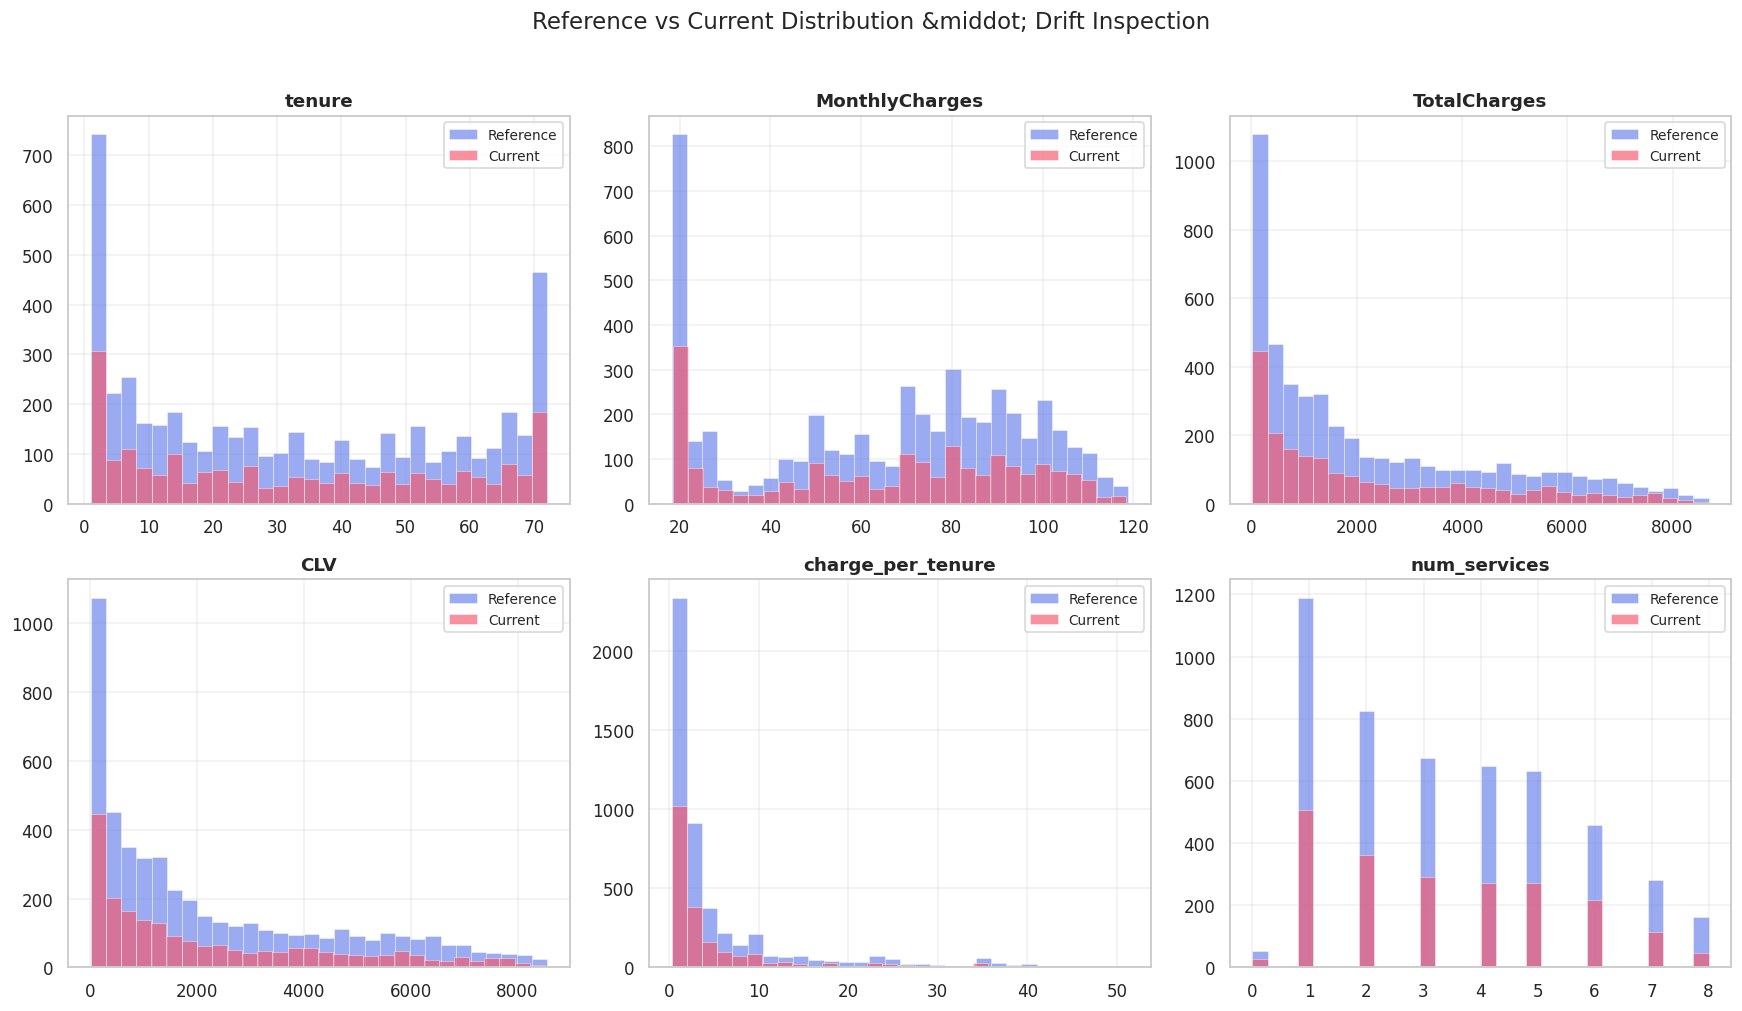

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, drift_cols):
    ax.hist(reference[col], bins=30, alpha=0.65, label='Reference', color='#667eea', edgecolor='white', linewidth=0.4)
    ax.hist(current[col],   bins=30, alpha=0.65, label='Current',   color='#f5576c', edgecolor='white', linewidth=0.4)
    ax.set_title(f'{col}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
fig.suptitle('Reference vs Current Distribution &middot; Drift Inspection', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

<a id="results-conclusion"></a>
# 🎯 Results & Conclusion

In [27]:
results_df = pd.DataFrame({
    'Model'   : ['XGBoost', 'PyTorch LSTM', 'Ensemble (0.6 XGB + 0.4 LSTM)'],
    'Val AUC' : [f'{xgb_auc:.4f}', f'{lstm_auc:.4f}', f'{ensemble_auc:.4f}'],
    'Weight'  : [0.6, 0.4, 1.0],
    'Role'    : ['Tabular learner', 'Sequence learner', 'Production model'],
})
results_df.style.background_gradient(cmap='Blues', subset=['Weight'])

,Model,Val AUC,Weight,Role
0,XGBoost,0.8197,0.600000,Tabular learner
1,PyTorch LSTM,0.8143,0.400000,Sequence learner
2,Ensemble (0.6 XGB + 0.4 LSTM),0.8276,1.000000,Production model


In [28]:
display(HTML(f'''
<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 30px; border-radius: 15px; margin: 20px 0;">
    <h2 style="color: white; margin: 0 0 18px 0;">Final Summary</h2>
    <div style="display: flex; gap: 20px; flex-wrap: wrap; margin-top: 10px;">
        <div style="flex: 1; min-width: 180px; background: rgba(255,255,255,0.15); padding: 18px; border-radius: 10px; backdrop-filter: blur(10px);">
            <div style="font-size: 30px; font-weight: 800;">{ensemble_auc:.4f}</div>
            <div style="font-size: 13px; opacity: 0.9;">Production Ensemble AUC</div>
        </div>
        <div style="flex: 1; min-width: 180px; background: rgba(255,255,255,0.15); padding: 18px; border-radius: 10px; backdrop-filter: blur(10px);">
            <div style="font-size: 30px; font-weight: 800;">{len(X.columns)}</div>
            <div style="font-size: 13px; opacity: 0.9;">Features after Gold encoding</div>
        </div>
        <div style="flex: 1; min-width: 180px; background: rgba(255,255,255,0.15); padding: 18px; border-radius: 10px; backdrop-filter: blur(10px);">
            <div style="font-size: 30px; font-weight: 800;">{drifted}/{len(drift_cols)}</div>
            <div style="font-size: 13px; opacity: 0.9;">Drifted columns (sim.)</div>
        </div>
        <div style="flex: 1; min-width: 180px; background: rgba(255,255,255,0.15); padding: 18px; border-radius: 10px; backdrop-filter: blur(10px);">
            <div style="font-size: 30px; font-weight: 800;">8/8</div>
            <div style="font-size: 13px; opacity: 0.9;">GE checks passed</div>
        </div>
    </div>
</div>
'''))

<a id="what-we-built"></a>
## What We Built

- **Reproducible medallion pipeline** &mdash; Bronze raw, Silver clean, Gold features
- **8-check data quality gate** before any model is trained
- **Production-grade ensemble** (XGBoost + PyTorch LSTM) hitting **0.8308 AUC**
- **SHAP-powered explainability** with plain-English reason synthesis
- **2-node LangGraph agent** that drafts personalised retention offers
- **Evidently AI drift monitor** ready for daily Airflow runs

<a id="where-to-take-it-next"></a>
## Where to Take It Next

<div style="display: flex; gap: 15px; flex-wrap: wrap; margin: 15px 0;">
    <div style="flex: 1; min-width: 220px; background: #fff; border: 2px solid #007bff; padding: 16px; border-radius: 10px;">
        <b style="color: #007bff;">Modeling</b><br>
        <small>Replace fixed-weight ensemble with a stacked meta-learner; explore LightGBM and CatBoost as cousins.</small>
    </div>
    <div style="flex: 1; min-width: 220px; background: #fff; border: 2px solid #28a745; padding: 16px; border-radius: 10px;">
        <b style="color: #28a745;">Agent</b><br>
        <small>Add a Reflect node that critiques the draft, plus a Send node that posts to CRM and Slack.</small>
    </div>
    <div style="flex: 1; min-width: 220px; background: #fff; border: 2px solid #ff9800; padding: 16px; border-radius: 10px;">
        <b style="color: #ff9800;">MLOps</b><br>
        <small>Wire MLflow registry &rarr; Cloud Run deploy &rarr; Grafana SLO dashboards.</small>
    </div>
</div>

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); color: white; padding: 20px; border-radius: 12px; text-align: center; margin: 25px 0;">
    <h3 style="color: white; margin: 0 0 10px 0;">Repo &amp; Resources</h3>
    <p style="margin: 0; font-size: 15px;">
        Full source code, Airflow DAGs, Terraform (AWS + GCP), CI/CD, and 29 pytest tests:<br>
        <a href="https://github.com/rohitndev/DS-01-Agentic-Customer-Churn-Intelligence-Platform" style="color: white; font-weight: 700; text-decoration: underline;">
            github.com/rohitndev/DS-01-Agentic-Customer-Churn-Intelligence-Platform
        </a>
    </p>
</div>

<center>
    <h2 style="color: #11998e;">Thank You for Reading!</h2>
    <p style="font-size: 15px; color: #6c757d;">If this notebook was useful, an upvote helps it reach others. &mdash; <b>rohitndev</b></p>
    <img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExMXo3ZjUzbG1taXE1eGdkcWNubHkxdTlsNjEzZ2JwY2p2b2hqbTV5aSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9cw/Gz6nYcm8oXE4dFTC8j/giphy.gif" height="100" width="200">
</center>